In [46]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import os
from PIL import Image

In [47]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [48]:
LABELS = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
          'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion',
          'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other',
          'Pneumonia', 'Pneumothorax', 'Support Devices']

IMG_DIR = r"D:\omer files\projects\NMIMS\cxr_project"

In [49]:
class CXRDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform = None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

        def build_path(row):
            subj = f"p{str(row['subject_id'])[:2]}/p{row['subject_id']}"
            study = f"s{row['study_id']}"
            return os.path.join('files', subj, study, f"{row['dicom_id']}.jpg")
        self.df['rel_path'] = self.df.apply(build_path, axis=1)

        self.df['full_path'] = self.df['rel_path'].apply(lambda p: os.path.join(img_dir, p))
        before = len(self.df)
        self.df = self.df[self.df['full_path'].apply(os.path.exists)].reset_index(drop = True)
        print(f"{csv_path}: {len(self.df)}/{before} images found on disk")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['full_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        labels = torch.tensor(row[LABELS].values.astype('float32'))
        return img, labels

In [50]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness = 0.1, contrast = 0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

In [51]:
train_ds = CXRDataset('subset_train.csv', IMG_DIR, transform = train_transform)
val_ds = CXRDataset('subset_val.csv', IMG_DIR, transform = eval_transform)
test_ds = CXRDataset('subset_test.csv', IMG_DIR, transform = eval_transform)

train_loader = DataLoader(train_ds, batch_size = 32, shuffle = True, num_workers = 0)
val_loader = DataLoader(val_ds, batch_size = 32, shuffle = False, num_workers = 0)
test_loader = DataLoader(test_ds, batch_size = 32, shuffle = False, num_workers = 0)

subset_train.csv: 5537/5537 images found on disk
subset_val.csv: 300/300 images found on disk
subset_test.csv: 300/300 images found on disk


In [52]:
# we first reload our model arch and load our best weights
model = models.resnet50(weights = None)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(LABELS))
model.load_state_dict(torch.load('best_model.pth', map_location = device))
model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [53]:
# we now implement Grad-CAM
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inputt, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = output[0, class_idx]
        score.backward(retain_graph = True)

        gradients = self.gradients[0]
        activations = self.activations[0]
        weights = gradients.mean(dim = (1, 2))

        cam = torch.zeros(activations.shape[1:], dtype = torch.float32).to(device)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = F.relu(cam)
        cam = cam.cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, output.detach().cpu().numpy()[0]

In [54]:
# our target will be the last convolutional block. layer 4 is the standard for a Grad-CAM on top of ResNet
target_layer = model.layer4[-1]
gradcam = GradCAM(model, target_layer)

In [55]:
# we now denormalize the helper to display the image appropriately
def denormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    img = np.clip(img, 0, 1)
    return img

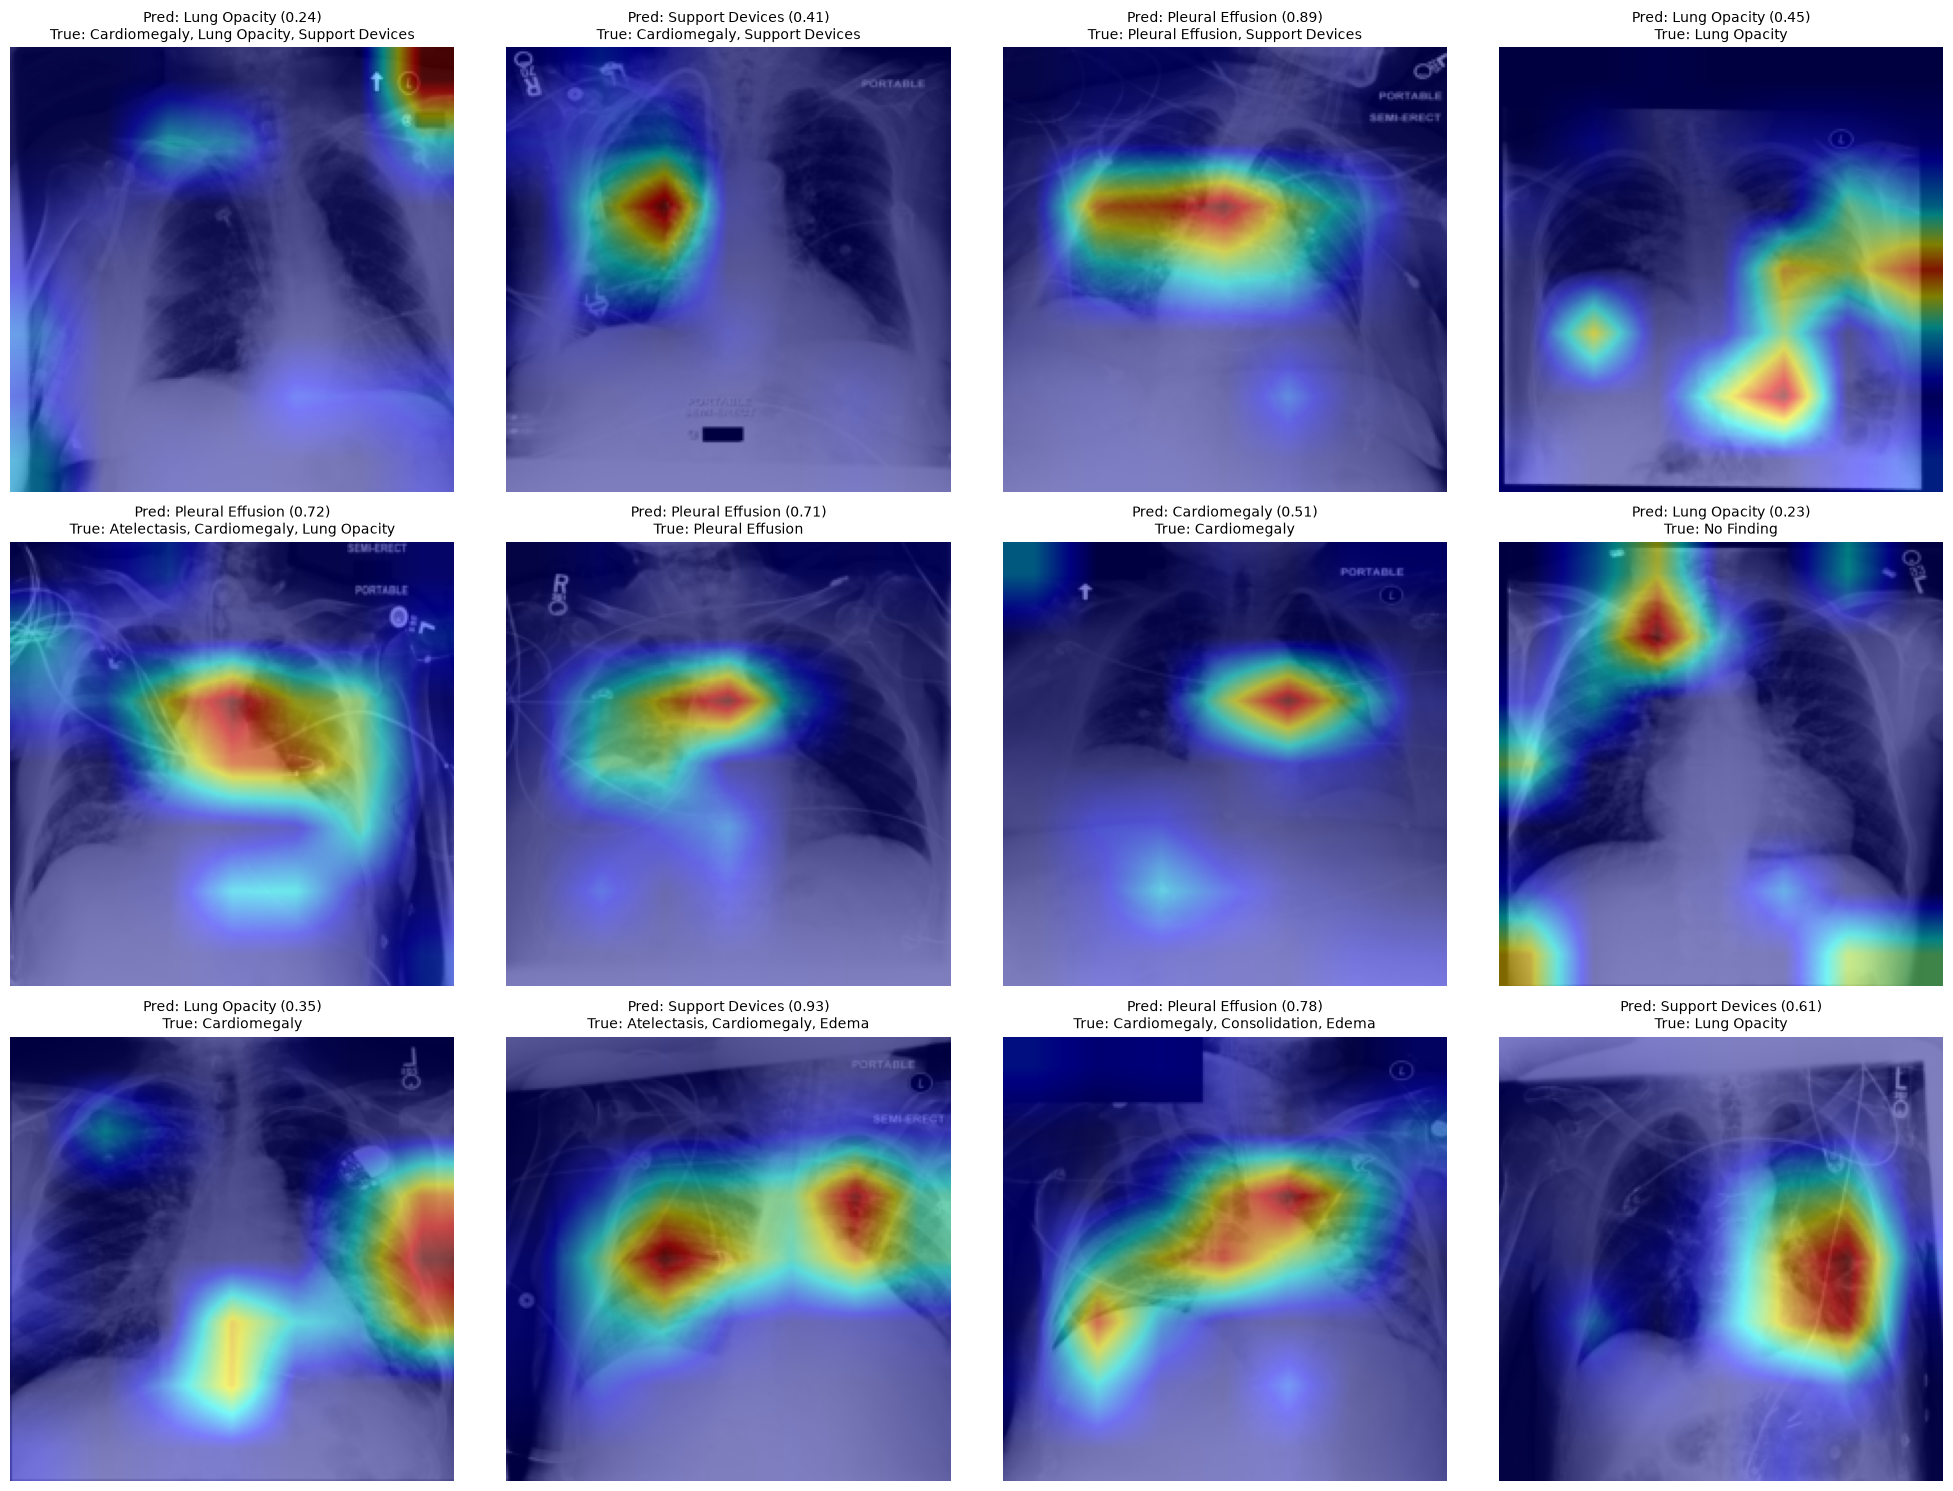

Saved to gradcam_samples.png


In [56]:
# and now, we visualize on a few samples from the test set
NUM_SAMPLES = 12
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

sample_indices = np.random.choice(len(test_ds), NUM_SAMPLES, replace=False)

for ax, idx in zip(axes, sample_indices):
    img_tensor, true_labels = test_ds[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0].cpu().numpy()

    top_class_idx = int(np.argmax(probs))
    top_class_name = LABELS[top_class_idx]
    top_prob = probs[top_class_idx]

    cam, _ = gradcam.generate(input_tensor, top_class_idx)

    orig_img = denormalize(img_tensor)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.5 * orig_img + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)

    true_positive_labels = [LABELS[i] for i, v in enumerate(true_labels) if v == 1]

    ax.imshow(overlay)
    ax.set_title(f"Pred: {top_class_name} ({top_prob:.2f})\nTrue: {', '.join(true_positive_labels[:3])}",
                 fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('gradcam_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to gradcam_samples.png")